# Clinical Phenotype Discovery in Dengue Patients using Gaussian Mixture Models (GMM)

## Project Objective

To identify clinically meaningful dengue patient phenotypes using unsupervised machine learning and validate them against independent clinical outcomes.

#  1.Import Required Libraries

In [1]:
import pandas as pd

# 2. Data Loading

In [2]:
df = pd.read_excel("Dengue_Retrospective dataset.xlsx")

# 3. Initial Dataset Inspection

In [3]:
df.head()

,Unnamed: 0,"Coding : Green (demographic), Blue (Clinical features), Grey (Lab investigations), Orange (outcomes)",Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48
0,Sl No,HospNo,Patientname,Age,Sex,Year,Month,DOI,DM,HTN,...,Troponin,7d_Death,"14d_Death (1 = Death, 2 =DAMA)",28d_Death,Total days of stay,"ICU/HDU admission 1= Yes, 0=No",Shock,Requirement of Mechanical Ventilation/PPV,Requirement of dialysis,Remarks
1,1,02636758,SAHIL CHAUDHARY,30,1,2019,12,6,0,0,...,ND,NaN,0,NaN,9,0,0,0,0,Scrub Typhus Coinfection
2,2,03412694,MAHENDRA K,16,1,2019,12,15,0,0,...,ND,NaN,0,NaN,9,1,0,0,0,NaN
3,3,03412304,SOORYAKANTHAMMA,76,2,2019,12,3,1,1,...,ND,NaN,0,NaN,13,1,0,0,0,Assoc fall & femur fracture
4,4,03413263,NAVEENA N,26,1,2019,12,3,0,0,...,ND,NaN,0,NaN,6,NaN,0,0,0,NaN


In [4]:
df.shape

(1948, 49)

In [5]:
df.columns

Index(['Unnamed: 0',
       'Coding : Green (demographic), Blue (Clinical features), Grey (Lab investigations), Orange (outcomes)',
       'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6',
       'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11',
       'Unnamed: 12', 'Unnamed: 13', 'Unnamed: 14', 'Unnamed: 15',
       'Unnamed: 16', 'Unnamed: 17', 'Unnamed: 18', 'Unnamed: 19',
       'Unnamed: 20', 'Unnamed: 21', 'Unnamed: 22', 'Unnamed: 23',
       'Unnamed: 24', 'Unnamed: 25', 'Unnamed: 26', 'Unnamed: 27',
       'Unnamed: 28', 'Unnamed: 29', 'Unnamed: 30', 'Unnamed: 31',
       'Unnamed: 32', 'Unnamed: 33', 'Unnamed: 34', 'Unnamed: 35',
       'Unnamed: 36', 'Unnamed: 37', 'Unnamed: 38', 'Unnamed: 39',
       'Unnamed: 40', 'Unnamed: 41', 'Unnamed: 42', 'Unnamed: 43',
       'Unnamed: 44', 'Unnamed: 45', 'Unnamed: 46', 'Unnamed: 47',
       'Unnamed: 48'],
      dtype='object')

In [6]:
df.head(10)

,Unnamed: 0,"Coding : Green (demographic), Blue (Clinical features), Grey (Lab investigations), Orange (outcomes)",Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,...,Unnamed: 39,Unnamed: 40,Unnamed: 41,Unnamed: 42,Unnamed: 43,Unnamed: 44,Unnamed: 45,Unnamed: 46,Unnamed: 47,Unnamed: 48
0,Sl No,HospNo,Patientname,Age,Sex,Year,Month,DOI,DM,HTN,...,Troponin,7d_Death,"14d_Death (1 = Death, 2 =DAMA)",28d_Death,Total days of stay,"ICU/HDU admission 1= Yes, 0=No",Shock,Requirement of Mechanical Ventilation/PPV,Requirement of dialysis,Remarks
1,1,02636758,SAHIL CHAUDHARY,30,1,2019,12,6,0,0,...,ND,NaN,0,NaN,9,0,0,0,0,Scrub Typhus Coinfection
2,2,03412694,MAHENDRA K,16,1,2019,12,15,0,0,...,ND,NaN,0,NaN,9,1,0,0,0,NaN
3,3,03412304,SOORYAKANTHAMMA,76,2,2019,12,3,1,1,...,ND,NaN,0,NaN,13,1,0,0,0,Assoc fall & femur fracture
4,4,03413263,NAVEENA N,26,1,2019,12,3,0,0,...,ND,NaN,0,NaN,6,NaN,0,0,0,NaN
5,5,03413474,THIMMAPPA K AMIN,51,1,2019,12,5,0,0,...,ND,NaN,0,NaN,6,NaN,0,0,0,NaN
6,6,03413670,MANJUNATHA ACHARYA,29,1,2019,12,5,0,0,...,ND,NaN,0,NaN,7,NaN,0,0,0,NaN
7,7,03413692,MOHAMMED SADIQ B L,49,1,2019,12,7,1,0,...,ND,NaN,0,NaN,3,NaN,0,0,0,NaN
8,8,03414681,GAYATHRI L,38,2,2019,12,6,0,0,...,ND,NaN,0,NaN,3,NaN,0,0,0,NaN
9,9,03414709,PARVATHAMMA,69,2,2019,12,5,1,0,...,ND,NaN,0,NaN,5,NaN,0,0,0,NaN


In [7]:
df = pd.read_excel("Dengue_Retrospective dataset.xlsx", header=1)

In [8]:
df.head()

,Sl No,HospNo,Patientname,Age,Sex,Year,Month,DOI,DM,HTN,...,Troponin,7d_Death,"14d_Death (1 = Death, 2 =DAMA)",28d_Death,Total days of stay,"ICU/HDU admission 1= Yes, 0=No",Shock,Requirement of Mechanical Ventilation/PPV,Requirement of dialysis,Remarks
0,1.0,2636758,SAHIL CHAUDHARY,30.0,1.0,2019.0,12.0,6,0.0,0.0,...,ND,NaN,0.0,NaN,9.0,0.0,0,0,0.0,Scrub Typhus Coinfection
1,2.0,3412694,MAHENDRA K,16.0,1.0,2019.0,12.0,15,0.0,0.0,...,ND,NaN,0.0,NaN,9.0,1.0,0,0,0.0,NaN
2,3.0,3412304,SOORYAKANTHAMMA,76.0,2.0,2019.0,12.0,3,1.0,1.0,...,ND,NaN,0.0,NaN,13.0,1.0,0,0,0.0,Assoc fall & femur fracture
3,4.0,3413263,NAVEENA N,26.0,1.0,2019.0,12.0,3,0.0,0.0,...,ND,NaN,0.0,NaN,6.0,NaN,0,0,0.0,NaN
4,5.0,3413474,THIMMAPPA K AMIN,51.0,1.0,2019.0,12.0,5,0.0,0.0,...,ND,NaN,0.0,NaN,6.0,NaN,0,0,0.0,NaN


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1947 entries, 0 to 1946
Data columns (total 49 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Sl No                                      1396 non-null   float64
 1   HospNo                                     1947 non-null   int64  
 2   Patientname                                1396 non-null   object 
 3   Age                                        1396 non-null   float64
 4   Sex                                        1396 non-null   float64
 5   Year                                       1396 non-null   float64
 6   Month                                      1396 non-null   float64
 7   DOI                                        1389 non-null   object 
 8   DM                                         1389 non-null   float64
 9   HTN                                        1395 non-null   float64
 10  CKD                     

 # 4. Data Cleaning

In [10]:
import numpy as np

# 4.1 Standardization of Missing Values

In [11]:
df.replace(
    ["ND", "?", "NA", "N/A", "-", " ", "Unknown", "unknown"],
    np.nan,
    )

C:\Users\Ayush\AppData\Local\Temp\ipykernel_15516\360697096.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(


,Sl No,HospNo,Patientname,Age,Sex,Year,Month,DOI,DM,HTN,...,Troponin,7d_Death,"14d_Death (1 = Death, 2 =DAMA)",28d_Death,Total days of stay,"ICU/HDU admission 1= Yes, 0=No",Shock,Requirement of Mechanical Ventilation/PPV,Requirement of dialysis,Remarks
0,1.0,2636758,SAHIL CHAUDHARY,30.0,1.0,2019.0,12.0,6,0.0,0.0,...,NaN,NaN,0.0,NaN,9.0,0.0,0,0,0.0,Scrub Typhus Coinfection
1,2.0,3412694,MAHENDRA K,16.0,1.0,2019.0,12.0,15,0.0,0.0,...,NaN,NaN,0.0,NaN,9.0,1.0,0,0,0.0,NaN
2,3.0,3412304,SOORYAKANTHAMMA,76.0,2.0,2019.0,12.0,3,1.0,1.0,...,NaN,NaN,0.0,NaN,13.0,1.0,0,0,0.0,Assoc fall & femur fracture
3,4.0,3413263,NAVEENA N,26.0,1.0,2019.0,12.0,3,0.0,0.0,...,NaN,NaN,0.0,NaN,6.0,NaN,0,0,0.0,NaN
4,5.0,3413474,THIMMAPPA K AMIN,51.0,1.0,2019.0,12.0,5,0.0,0.0,...,NaN,NaN,0.0,NaN,6.0,NaN,0,0,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1942,NaN,5038669,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1943,NaN,5054949,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1944,NaN,5089252,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1945,NaN,5093562,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df.isnull().sum()

Sl No                                         551
HospNo                                          0
Patientname                                   551
Age                                           551
Sex                                           551
Year                                          551
Month                                         551
DOI                                           558
DM                                            558
HTN                                           552
CKD                                           552
CAD/ IHD                                      731
CLD                                           739
COPD                                          740
Rash                                          712
Bleeds                                        746
Site of Bleeds                                687
Pain abdomen                                  702
Loose stools0                                 737
Cough                                         737


# 4.2 Removal of Non-Patient Records

In [13]:
df=df.dropna(subset=["Patientname"])

In [14]:
df.shape

(1396, 49)

In [15]:
df.tail()

,Sl No,HospNo,Patientname,Age,Sex,Year,Month,DOI,DM,HTN,...,Troponin,7d_Death,"14d_Death (1 = Death, 2 =DAMA)",28d_Death,Total days of stay,"ICU/HDU admission 1= Yes, 0=No",Shock,Requirement of Mechanical Ventilation/PPV,Requirement of dialysis,Remarks
1391,1397.0,3863328,DEERAJ B SHETTY,33.0,1.0,2024.0,1.0,4,0.0,0.0,...,ND,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN
1392,1398.0,3873720,ANITHA H S,15.0,2.0,2024.0,2.0,5,1.0,1.0,...,ND,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN
1393,1399.0,3874377,SHUKALATHA R RAI,65.0,2.0,2024.0,2.0,7,0.0,0.0,...,ND,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN
1394,1400.0,3864329,DHARMATEJA C H,24.0,1.0,2024.0,1.0,4,0.0,0.0,...,ND,NaN,0.0,NaN,3.0,NaN,0,NaN,NaN,NaN
1395,1401.0,3245817,NUTHAN KUMAR,38.0,1.0,2024.0,1.0,NaN,NaN,NaN,...,ND,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
df.isnull().sum()

Sl No                                           0
HospNo                                          0
Patientname                                     0
Age                                             0
Sex                                             0
Year                                            0
Month                                           0
DOI                                             7
DM                                              7
HTN                                             1
CKD                                             1
CAD/ IHD                                      180
CLD                                           188
COPD                                          189
Rash                                          161
Bleeds                                        195
Site of Bleeds                                136
Pain abdomen                                  151
Loose stools0                                 186
Cough                                         186


In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.describe()

,Sl No,HospNo,Age,Sex,Year,Month,DM,HTN,CKD,CAD/ IHD,...,COPD,Rash,Bleeds,Pain abdomen,Loose stools0,Cough,"14d_Death (1 = Death, 2 =DAMA)",Total days of stay,"ICU/HDU admission 1= Yes, 0=No",Requirement of dialysis
count,1396.000000,1.396000e+03,1396.000000,1396.000000,1396.000000,1396.000000,1389.000000,1395.000000,1395.000000,1216.000000,...,1207.000000,1235.000000,1201.000000,1245.000000,1210.000000,1210.000000,1189.000000,1389.000000,344.000000,1185.000000
mean,701.699140,3.526206e+06,39.634670,1.328080,2021.937679,7.275788,0.175666,0.154122,0.010036,0.039474,...,0.009114,0.259919,0.161532,0.284337,0.152066,0.147934,0.047098,5.920086,0.994186,0.017722
std,404.502397,3.577416e+05,15.917027,0.469682,1.145219,3.240738,0.380673,0.361195,0.099711,0.194799,...,0.095068,0.444274,0.467852,0.453057,0.359233,0.355181,0.271178,3.284771,0.076138,0.131993
min,1.000000,2.358666e+06,15.000000,1.000000,2019.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,351.750000,3.425979e+06,26.000000,1.000000,2021.000000,6.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,1.000000,0.000000
50%,702.500000,3.583068e+06,38.000000,1.000000,2022.000000,8.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,1.000000,0.000000
75%,1051.250000,3.783288e+06,52.000000,2.000000,2023.000000,10.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,7.000000,1.000000,0.000000
max,1401.000000,5.088154e+06,96.000000,2.000000,2024.000000,12.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,2.000000,2.000000,2.000000,1.000000,1.000000,2.000000,45.000000,1.000000,1.000000


In [19]:
for col in df.columns:
    print(repr(col))

'Sl No'
'HospNo'
'Patientname'
'Age'
'Sex'
'Year'
'Month'
'DOI '
'DM'
'HTN'
'CKD'
'CAD/ IHD'
'CLD'
'COPD'
'Rash '
'Bleeds'
'Site of Bleeds'
'Pain abdomen'
'Loose stools0'
'Cough'
'HR'
'Hb '
'Haematocrit'
'WBC'
'Plt\n'
'N'
'L'
'Urea 1 '
'Creat 1'
'Total Bil 1'
'S. Albumin  '
'AST 1'
'ALT 1'
'ALP  1'
'PT'
'APTT 1'
'INR 1'
'CRP 1'
'CPK 1'
'Troponin'
'7d_Death'
'14d_Death (1 = Death, 2 =DAMA)'
'28d_Death'
'Total days of stay'
'ICU/HDU  admission 1= Yes, 0=No'
'Shock'
'Requirement of Mechanical Ventilation/PPV'
'Requirement of dialysis'
'Remarks'


# 5. Missing Value Imputation

In [20]:
lab_cols = [
    "Hb ",
    "WBC",
    "Haematocrit",
    "Plt\n",
    "N",
    "L",
    "Urea 1 ",
    "Creat 1",
    "Total Bil 1",
    "S. Albumin  ",
    "AST 1",
    "ALT 1",
    "ALT 1",
    "PT",
    "APTT 1",
    "INR 1",
    "CRP 1",
    "CPK 1",
    "Troponin"
]

In [21]:
for col in lab_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [22]:
for col in lab_cols:
    df[col] = df[col].fillna(df[col].median())

In [23]:
clinical_cols = [
    "DM",
    "HTN",
    "CKD",
    "CAD/ IHD",
    "CLD",
    "COPD",
    "Rash ",
    "Bleeds",
    "Pain abdomen",
    "Loose stools0",
    "Shock",
    "ICU/HDU  admission 1= Yes, 0=No",
    "Requirement of dialysis",
    "Requirement of Mechanical Ventilation/PPV",
    "28d_Death",
    "7d_Death",
    "14d_Death (1 = Death, 2 =DAMA)"
]

In [24]:
df[clinical_cols] = df[clinical_cols].fillna(0)

In [25]:
df["DOI "] = pd.to_numeric(df["DOI "], errors="coerce")
df["DOI "] = df["DOI "].fillna(df["DOI "].median())


# 6. Exploratory Data Analysis (EDA)

 # 6.1 Descriptive Statistics

In [26]:
df.describe()

,Sl No,HospNo,Age,Sex,Year,Month,DOI,DM,HTN,CKD,...,PT,APTT 1,INR 1,CRP 1,CPK 1,Troponin,"14d_Death (1 = Death, 2 =DAMA)",Total days of stay,"ICU/HDU admission 1= Yes, 0=No",Requirement of dialysis
count,1396.000000,1.396000e+03,1396.000000,1396.000000,1396.000000,1396.000000,1396.000000,1396.000000,1396.000000,1396.000000,...,1396.000000,1396.000000,1396.000000,1396.000000,1396.000000,1396.000000,1396.000000,1389.000000,1396.000000,1396.000000
mean,701.699140,3.526206e+06,39.634670,1.328080,2021.937679,7.275788,4.728510,0.174785,0.154011,0.010029,...,11.634814,37.691433,1.128825,23.108431,403.079388,0.016351,0.040115,5.920086,0.244986,0.015043
std,404.502397,3.577416e+05,15.917027,0.469682,1.145219,3.240738,2.720176,0.379919,0.361089,0.099675,...,3.624715,9.376825,1.843492,44.575451,2050.120914,0.074126,0.250810,3.284771,0.430233,0.121767
min,1.000000,2.358666e+06,15.000000,1.000000,2019.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,9.400000,0.890000,0.820000,0.190000,0.016000,0.003000,0.000000,1.000000,0.000000,0.000000
25%,351.750000,3.425979e+06,26.000000,1.000000,2021.000000,6.000000,3.000000,0.000000,0.000000,0.000000,...,10.900000,33.775000,0.970000,4.640000,212.000000,0.009000,0.000000,4.000000,0.000000,0.000000
50%,702.500000,3.583068e+06,38.000000,1.000000,2022.000000,8.000000,4.000000,0.000000,0.000000,0.000000,...,11.200000,36.200000,1.000000,9.010000,212.000000,0.009000,0.000000,5.000000,0.000000,0.000000
75%,1051.250000,3.783288e+06,52.000000,2.000000,2023.000000,10.000000,6.000000,0.000000,0.000000,0.000000,...,11.600000,39.000000,1.030000,19.882500,212.000000,0.009000,0.000000,7.000000,0.000000,0.000000
max,1401.000000,5.088154e+06,96.000000,2.000000,2024.000000,12.000000,30.000000,1.000000,1.000000,1.000000,...,113.000000,117.300000,42.900000,530.000000,64185.000000,1.880000,2.000000,45.000000,1.000000,1.000000


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1396 entries, 0 to 1395
Data columns (total 49 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   Sl No                                      1396 non-null   float64
 1   HospNo                                     1396 non-null   int64  
 2   Patientname                                1396 non-null   object 
 3   Age                                        1396 non-null   float64
 4   Sex                                        1396 non-null   float64
 5   Year                                       1396 non-null   float64
 6   Month                                      1396 non-null   float64
 7   DOI                                        1396 non-null   float64
 8   DM                                         1396 non-null   float64
 9   HTN                                        1396 non-null   float64
 10  CKD                          

In [28]:
df[lab_cols].isnull().sum()

Hb              0
WBC             0
Haematocrit     0
Plt\n           0
N               0
L               0
Urea 1          0
Creat 1         0
Total Bil 1     0
S. Albumin      0
AST 1           0
ALT 1           0
ALT 1           0
PT              0
APTT 1          0
INR 1           0
CRP 1           0
CPK 1           0
Troponin        0
dtype: int64

# 6.2 Distribution Analysis


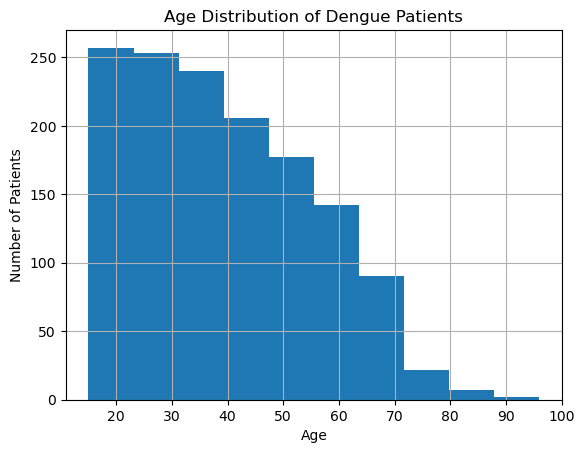

In [29]:
import matplotlib.pyplot as plt
df["Age"].hist()
plt.title("Age Distribution of Dengue Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()

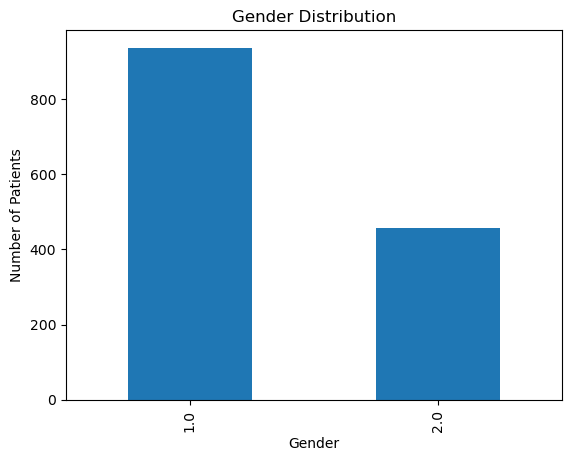

In [30]:
df["Sex"].value_counts().plot(kind="bar")
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Patients")
plt.show()          
          

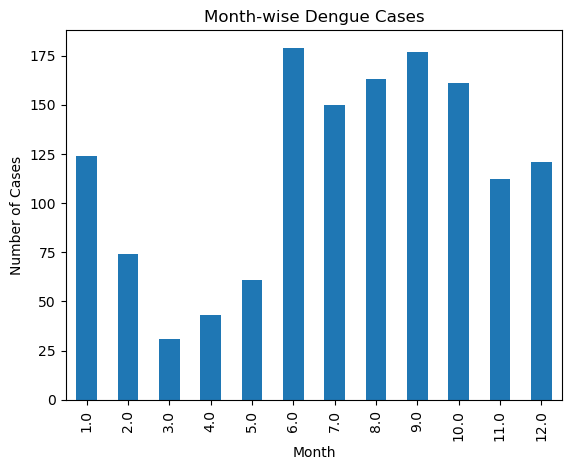

In [31]:
df["Month"].value_counts().sort_index().plot(kind="bar")
plt.title("Month-wise Dengue Cases")
plt.xlabel("Month")
plt.ylabel("Number of Cases")

plt.show()


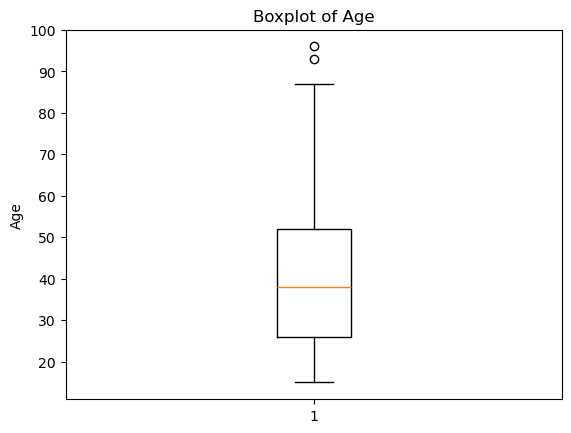

In [32]:
plt.boxplot(df["Age"].dropna())

plt.title("Boxplot of Age")

plt.ylabel("Age")

plt.show()

In [33]:
df.corr(numeric_only=True)

,Sl No,HospNo,Age,Sex,Year,Month,DOI,DM,HTN,CKD,...,PT,APTT 1,INR 1,CRP 1,CPK 1,Troponin,"14d_Death (1 = Death, 2 =DAMA)",Total days of stay,"ICU/HDU admission 1= Yes, 0=No",Requirement of dialysis
Sl No,1.000000,0.242401,-0.075887,-0.006223,0.955492,0.135369,0.057888,-0.038621,-0.038135,0.014334,...,0.005545,0.023277,-0.069939,0.029519,0.018902,0.015415,-0.028893,-0.074270,0.034283,0.017382
HospNo,0.242401,1.000000,-0.097341,-0.052892,0.253861,0.060929,0.072756,-0.055812,-0.094348,-0.035808,...,0.033987,0.025105,-0.008885,0.030877,-0.001665,-0.010544,0.023844,0.002402,0.008551,-0.003032
Age,-0.075887,-0.097341,1.000000,0.098315,-0.068064,-0.047810,-0.039462,0.358014,0.455185,0.094936,...,-0.019732,-0.050799,0.028366,0.177146,0.042362,0.070644,0.055568,0.151473,0.131471,0.067932
Sex,-0.006223,-0.052892,0.098315,1.000000,-0.009938,-0.077383,0.018708,0.060052,0.044223,0.006230,...,0.045203,-0.038357,0.001720,-0.024554,-0.058338,0.039414,0.009904,0.033786,0.027658,0.001383
Year,0.955492,0.253861,-0.068064,-0.009938,1.000000,0.130568,0.057386,-0.037554,-0.018377,0.030599,...,0.018016,0.025042,-0.086292,0.038528,0.013226,0.023564,-0.016247,-0.055619,0.055743,0.022149
Month,0.135369,0.060929,-0.047810,-0.077383,0.130568,1.000000,-0.001096,-0.033939,-0.017333,-0.030760,...,0.033527,0.019514,0.052541,0.048358,0.015581,-0.007729,0.011955,0.023541,0.074900,0.002195
DOI,0.057888,0.072756,-0.039462,0.018708,0.057386,-0.001096,1.000000,-0.032432,-0.037680,0.031200,...,-0.017180,-0.054458,0.029720,0.045730,-0.013394,0.031168,-0.027105,-0.014381,0.003583,-0.020124
DM,-0.038621,-0.055812,0.358014,0.060052,-0.037554,-0.033939,-0.032432,1.000000,0.347078,0.105117,...,-0.010512,0.033385,0.018788,0.111329,0.041222,0.020169,0.084348,0.107456,0.075536,0.082583
HTN,-0.038135,-0.094348,0.455185,0.044223,-0.018377,-0.017333,-0.037680,0.347078,1.000000,0.196059,...,0.008552,-0.022658,0.005301,0.111366,0.013564,0.056551,0.034632,0.134075,0.121486,0.126609
CKD,0.014334,-0.035808,0.094936,0.006230,0.030599,-0.030760,0.031200,0.105117,0.196059,1.000000,...,-0.011483,-0.015324,-0.007075,0.011125,-0.009233,0.005733,0.012571,0.057331,0.076396,0.164747


# 6.3 Correlation Analysis

In [34]:
import seaborn as sns
plt.figure(figsize=(12,8))


<Figure size 1200x800 with 0 Axes>

<Figure size 1200x800 with 0 Axes>

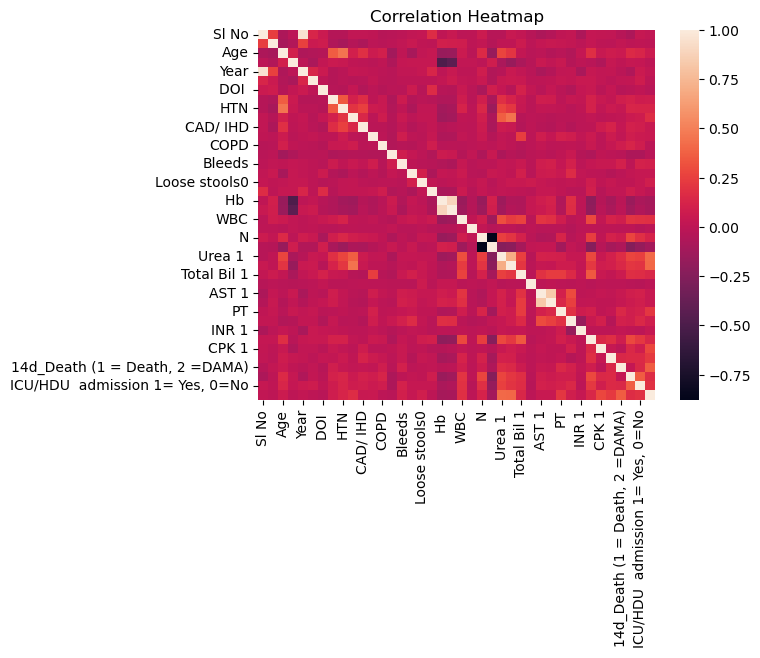

In [35]:
sns.heatmap(df.corr(numeric_only=True))
plt.title("Correlation Heatmap")

plt.show()

# 7. Feature Engineering

In [36]:
bins=[0,20, 40, 60, 80 , 100]
labels=["0-20","20-40","40-60","60-80","80-100"]
df["Age_Group"]=pd.cut(df["Age"], bins = bins, labels = labels)

In [37]:
age_percent = df["Age_Group"].value_counts(normalize=True) * 100

In [38]:
print(age_percent)

Age_Group
20-40     45.415473
40-60     32.163324
60-80     11.461318
0-20      10.458453
80-100     0.501433
Name: proportion, dtype: float64


In [39]:
import numpy as np

In [40]:
df["AST_log"] = np.log1p(df["AST 1"])
df["ALT_log"] = np.log1p(df["ALT 1"])

# 8. Feature Selection

In [41]:
gmm_features = [
    "Age",
    
    "DOI ",
    "DM",
    "HTN",
    "CKD",
    "Hb ",
    "WBC",
    "Haematocrit",
    "Plt\n",
    "AST_log",
    "ALT_log",
    "Creat 1",
    "Urea 1 ",
    "S. Albumin  ",
    "CRP 1"]

In [42]:
X=df[gmm_features]

In [43]:
X.isnull().sum()

Age             0
DOI             0
DM              0
HTN             0
CKD             0
Hb              0
WBC             0
Haematocrit     0
Plt\n           0
AST_log         0
ALT_log         0
Creat 1         0
Urea 1          0
S. Albumin      0
CRP 1           0
dtype: int64

# 9. Feature Scaling

In [44]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [45]:
X_scaled.shape

(1396, 15)

# 10. Gaussian Mixture Model (GMM)

In [46]:
from sklearn.mixture import GaussianMixture

In [47]:
gmm = GaussianMixture(
    n_components=4,
    random_state=42
)

In [48]:
gmm.fit(X_scaled)

,n_components,4
,covariance_type,'full'
,tol,0.001
,reg_covar,1e-06
,max_iter,100
,n_init,1
,init_params,'kmeans'
,weights_init,None
,means_init,None
,precisions_init,None
,random_state,42


# 11. Phenotype Assignment

In [49]:
clusters = gmm.predict(X_scaled)

In [50]:
df["Phenotype"]= clusters

In [51]:
df.head()

,Sl No,HospNo,Patientname,Age,Sex,Year,Month,DOI,DM,HTN,...,Total days of stay,"ICU/HDU admission 1= Yes, 0=No",Shock,Requirement of Mechanical Ventilation/PPV,Requirement of dialysis,Remarks,Age_Group,AST_log,ALT_log,Phenotype
0,1.0,2636758,SAHIL CHAUDHARY,30.0,1.0,2019.0,12.0,6.0,0.0,0.0,...,9.0,0.0,0,0,0.0,Scrub Typhus Coinfection,20-40,6.473891,6.822197,0
1,2.0,3412694,MAHENDRA K,16.0,1.0,2019.0,12.0,15.0,0.0,0.0,...,9.0,1.0,0,0,0.0,NaN,0-20,4.779123,4.330733,0
2,3.0,3412304,SOORYAKANTHAMMA,76.0,2.0,2019.0,12.0,3.0,1.0,1.0,...,13.0,1.0,0,0,0.0,Assoc fall & femur fracture,60-80,7.489971,6.504288,1
3,4.0,3413263,NAVEENA N,26.0,1.0,2019.0,12.0,3.0,0.0,0.0,...,6.0,0.0,0,0,0.0,NaN,20-40,3.433987,2.890372,3
4,5.0,3413474,THIMMAPPA K AMIN,51.0,1.0,2019.0,12.0,5.0,0.0,0.0,...,6.0,0.0,0,0,0.0,NaN,40-60,4.477337,3.135494,3


# 12. Cluster Distribution

In [52]:
df["Phenotype"].value_counts()

Phenotype
3    1010
2     311
0      46
1      29
Name: count, dtype: int64

# 13. Phenotype Profiling

In [53]:
df.groupby("Phenotype")[gmm_features].mean().round(2)

,Age,DOI,DM,HTN,CKD,Hb,WBC,Haematocrit,Plt\n,AST_log,ALT_log,Creat 1,Urea 1,S. Albumin,CRP 1
Phenotype,,,,,,,,,,,,,,,
0,33.39,9.59,0.04,0.02,0.00,13.39,7.27,32.53,20.04,4.63,4.47,0.82,19.17,3.85,15.98
1,55.31,5.34,0.48,0.66,0.48,11.33,11.90,34.09,0.92,4.73,4.13,4.56,110.69,3.27,89.86
2,51.80,4.71,0.41,0.63,0.00,13.35,8.53,39.31,0.85,4.72,4.36,1.18,35.75,3.64,54.67
3,35.72,4.50,0.10,0.00,0.00,14.59,4.75,42.93,0.70,4.77,4.34,0.89,19.50,4.34,11.80


# 14.Clinical Outcome Validation

# 14.1 ICU Admission

In [54]:
pd.crosstab(
    df["Phenotype"],
    df["ICU/HDU  admission 1= Yes, 0=No"],
    normalize="index"
)

"ICU/HDU admission 1= Yes, 0=No",0.0,1.0
Phenotype,,
0,0.782609,0.217391
1,0.241379,0.758621
2,0.614148,0.385852
3,0.811881,0.188119


# 14.2 Dialysis Requirement

In [55]:
pd.crosstab(
    df["Phenotype"],
    df["Requirement of dialysis"],
    normalize="index"
)


Requirement of dialysis,0.0,1.0
Phenotype,,
0,1.000000,0.000000
1,0.620690,0.379310
2,0.980707,0.019293
3,0.996040,0.003960


# 14.3 Shock

In [56]:
df.loc[
    df["Shock"]=="SEPSIS WITH SHOCK RECOVERED",
    "Shock"
] = 1


In [57]:
df.loc[df["Shock"]=="Patient had persistent bradycardia, isoprenaline was started in view of the same", "Shock"] = np.nan

In [58]:
df.loc[df["Shock"]==90, "Shock"] = np.nan

In [59]:
pd.crosstab(
    df["Phenotype"],
    df["Shock"],
    normalize="index"
)


Shock,0,1
Phenotype,,
0,0.956522,0.043478
1,0.758621,0.241379
2,0.935484,0.064516
3,0.990089,0.009911


# 14.4 Mechanical Ventilation

In [60]:
df.loc[
    df["Requirement of Mechanical Ventilation/PPV"] == "NIV STARTED",
    "Requirement of Mechanical Ventilation/PPV"
] = 1


In [61]:
pd.crosstab(
    df["Phenotype"],
    df["Requirement of Mechanical Ventilation/PPV"],
    normalize="index"
)

Requirement of Mechanical Ventilation/PPV,0,1,Oxygen to maintain saturation
Phenotype,,,
0,0.978261,0.021739,0.00000
1,0.689655,0.310345,0.00000
2,0.906752,0.093248,0.00000
3,0.984158,0.014851,0.00099


# 14.5 7-Day Mortality

In [62]:
pd.crosstab(
    df["Phenotype"],
    df["7d_Death"],
    normalize="index"
)

7d_Death,0,1,?
Phenotype,,,
0,0.978261,0.000000,0.021739
1,0.896552,0.103448,0.000000
2,0.974277,0.016077,0.009646
3,0.991089,0.003960,0.004950


# 14.6 28-Day Mortality

In [63]:
pd.crosstab(
    df["Phenotype"],
    df["28d_Death"],
    normalize="index"
)

28d_Death,0,1,?
Phenotype,,,
0,0.978261,0.000000,0.021739
1,0.793103,0.172414,0.034483
2,0.954984,0.032154,0.012862
3,0.990099,0.003960,0.005941


# 14.7 14-Day Mortality

In [64]:
pd.crosstab(
    df["Phenotype"],
    df["14d_Death (1 = Death, 2 =DAMA)"],
    normalize="index"
)

"14d_Death (1 = Death, 2 =DAMA)",0.0,1.0,2.0
Phenotype,,,
0,0.978261,0.000000,0.021739
1,0.793103,0.172414,0.034483
2,0.951768,0.035370,0.012862
3,0.983168,0.005941,0.010891


# 15. Summary

In [65]:
summary = df.groupby("Phenotype")[gmm_features].mean().round(2)
summary

,Age,DOI,DM,HTN,CKD,Hb,WBC,Haematocrit,Plt\n,AST_log,ALT_log,Creat 1,Urea 1,S. Albumin,CRP 1
Phenotype,,,,,,,,,,,,,,,
0,33.39,9.59,0.04,0.02,0.00,13.39,7.27,32.53,20.04,4.63,4.47,0.82,19.17,3.85,15.98
1,55.31,5.34,0.48,0.66,0.48,11.33,11.90,34.09,0.92,4.73,4.13,4.56,110.69,3.27,89.86
2,51.80,4.71,0.41,0.63,0.00,13.35,8.53,39.31,0.85,4.72,4.36,1.18,35.75,3.64,54.67
3,35.72,4.50,0.10,0.00,0.00,14.59,4.75,42.93,0.70,4.77,4.34,0.89,19.50,4.34,11.80


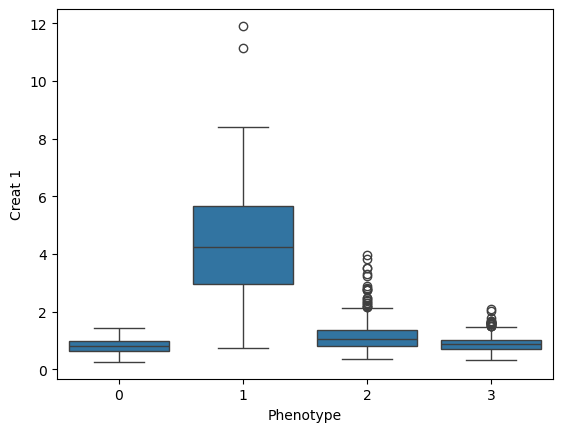

In [66]:

sns.boxplot(
    x="Phenotype",
    y="Creat 1",
    data=df
)

plt.show()

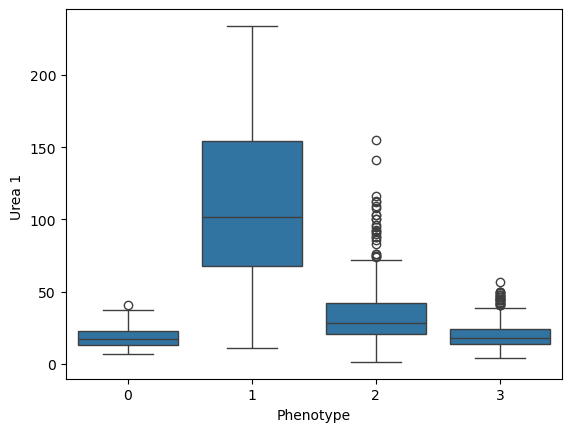

In [67]:
sns.boxplot(
    x="Phenotype",
    y="Urea 1 ",
    data=df
)

plt.show()

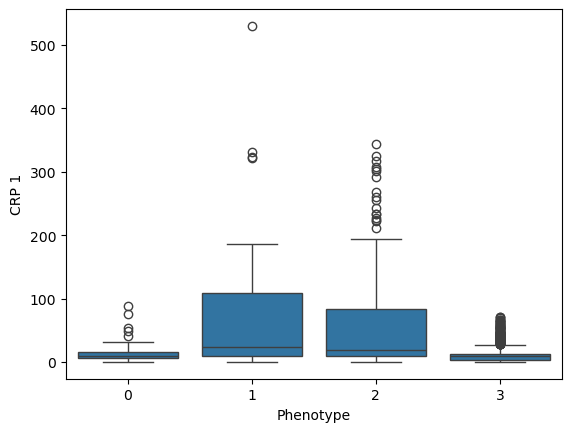

In [68]:
sns.boxplot(
    x="Phenotype",
    y="CRP 1",
    data=df
)

plt.show()

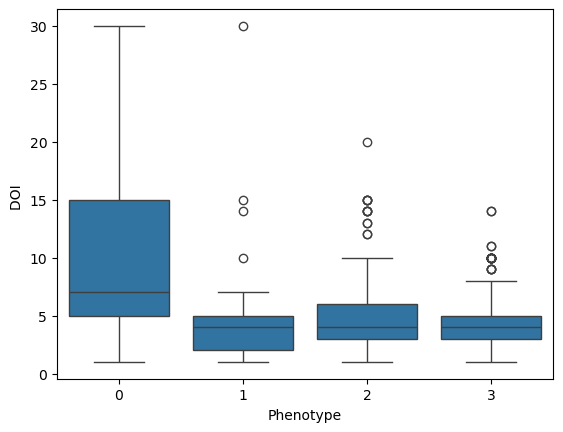

In [69]:
sns.boxplot(
    x="Phenotype",
    y="DOI ",
    data=df
)

plt.show()

# 16. Phenotype Interpretation
## Phenotype 0 – Late Presentation Phenotype
## Phenotype 1 – Severe Renal / High-Risk Phenotype
## Phenotype 2 – Intermediate Inflammatory Phenotype
## Phenotype 3 – Mild Dengue Phenotype

# 17. Internal Cluster Validation

In [70]:
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)

for k in range(2, 9):   # 2,3,4,5,6,7,8

    gmm = GaussianMixture(
        n_components=k,
        random_state=42
    )

    gmm.fit(X_scaled)

    clusters = gmm.predict(X_scaled)

    sil = silhouette_score(X_scaled, clusters)

    ch = calinski_harabasz_score(X_scaled, clusters)

    db = davies_bouldin_score(X_scaled, clusters)

    print(f"K={k}")
    print(f"Silhouette Score: {sil:.4f}")
    print(f"Calinski-Harabasz: {ch:.4f}")
    print(f"Davies-Bouldin: {db:.4f}")
    print("-"*40)

K=2
Silhouette Score: 0.2987
Calinski-Harabasz: 170.1485
Davies-Bouldin: 2.3680
----------------------------------------
K=3
Silhouette Score: 0.2182
Calinski-Harabasz: 149.4680
Davies-Bouldin: 2.2283
----------------------------------------
K=4
Silhouette Score: 0.2656
Calinski-Harabasz: 121.6425
Davies-Bouldin: 2.1379
----------------------------------------
K=5
Silhouette Score: 0.2191
Calinski-Harabasz: 123.0048
Davies-Bouldin: 2.6108
----------------------------------------
K=6
Silhouette Score: 0.2402
Calinski-Harabasz: 125.5715
Davies-Bouldin: 2.0357
----------------------------------------
K=7
Silhouette Score: 0.2201
Calinski-Harabasz: 95.4280
Davies-Bouldin: 2.3550
----------------------------------------
K=8
Silhouette Score: 0.1790
Calinski-Harabasz: 126.8052
Davies-Bouldin: 1.9462
----------------------------------------


# 18. Key Findings
- Four clinically meaningful phenotypes were identified.
- Phenotype 1 demonstrated the highest severity and mortality.
- Phenotype 3 represented the mildest clinical presentation.
- Clinical outcomes validated the relevance of the discovered phenotypes.
  

# 19. Conclusion
Gaussian Mixture Models successfully identified clinically meaningful dengue patient phenotypes using admission characteristics alone.

The Severe Renal–Inflammatory phenotype demonstrated substantially worse outcomes, including higher ICU admission, dialysis requirement, shock incidence, and mortality.

These findings highlight the potential utility of unsupervised learning for clinical risk stratification in dengue patients.